## Panning an oscillator's output

First start with some imports

In [13]:
import numpy as np
from matplotlib import pyplot as plt
from IPython.display import Audio, display

from constants import DEFAULT_SAMPLE_RATE
from engine import SineOscillator, ModulatedPanner, Chain
from utils import save_wave

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.size'] = 10

This example demonstrates modulated stereo panning using an LFO (Low Frequency Oscillator).
The pan position oscillates between left and right at 4 Hz, creating an auto-panning effect.

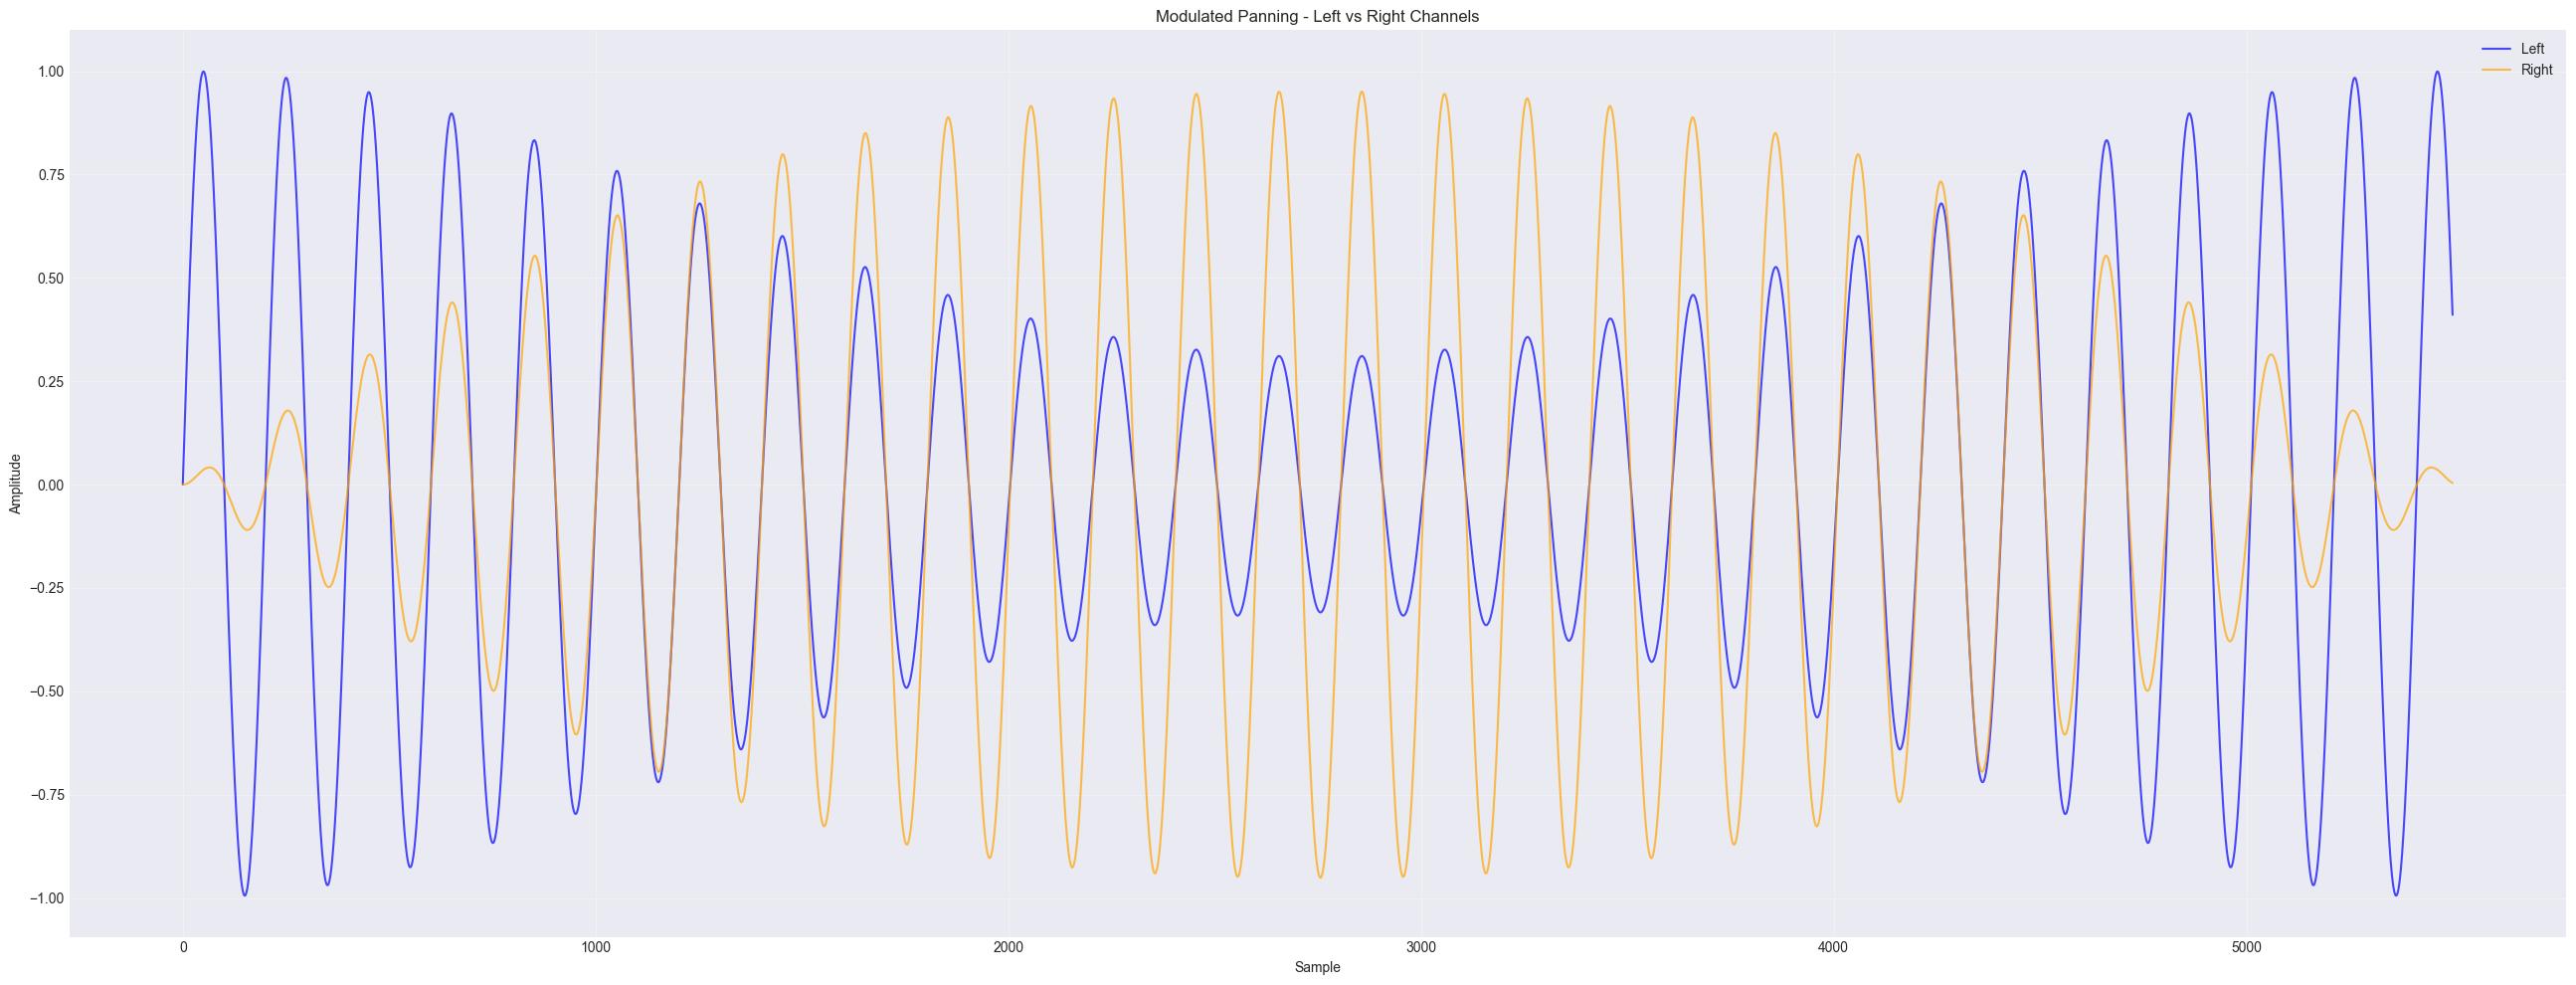

In [11]:
# Create a 220Hz sine wave with auto-panning at 4Hz
gen = Chain(
    SineOscillator(220),
    ModulatedPanner(SineOscillator(4, wave_range=(-0.8, 0.8)))
)

plt.figure(figsize=(26, 10))
wav = gen.get_samples(5500)
l, r = np.array(wav).T

plt.plot(l, label="Left", color="blue", alpha=0.7)
plt.plot(r, label="Right", color="orange", alpha=0.7)
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Modulated Panning - Left vs Right Channels")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
save_wave(l, r, filename="oscillators_v7_panning.wav", sample_rate=DEFAULT_SAMPLE_RATE)
display(Audio("oscillators_v7_panning.wav"))